<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/solved/04_varying_intercept.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 4 — Varying intercepts

In the previous notebooks, every participant shared the same regression line.

Here we build our first hierarchical model. Participants will have different baseline reaction times while sharing one population-level effect of sleep deprivation.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pandas==2.2.3" \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

g++ not available, if using conda: `conda install gxx`


PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. You can read about the original study here: [Belenky J Sleep Res. 2003](https://doi.org/10.1046/j.1365-2869.2003.00337.x)

Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

That zero point is scientifically meaningful, so every model in this sequence keeps `Days` on its natural scale.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

sleep = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = sleep.loc[sleep["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

print(f"{sleep['Subject'].nunique()} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


### A different look at the data

Instead of plotting all of the trajectories again, compare each participant's reaction time at baseline with the same participant's reaction time on day 7.

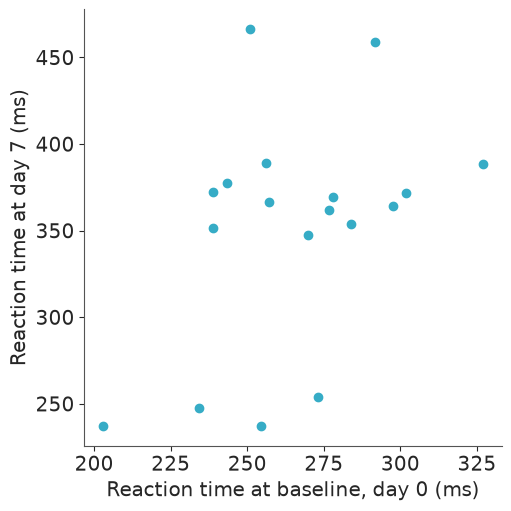

In [4]:
rt_by_day = sleep.pivot(index="Subject", columns="Days", values="Reaction")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(rt_by_day[0], rt_by_day[7])
ax.set(
    xlabel="Reaction time at baseline, day 0 (ms)",
    ylabel="Reaction time at day 7 (ms)",
)
plt.show()

Participants who are relatively fast at baseline also tend to be relatively fast later in the experiment. We want a model that can preserve these participant differences while still estimating an effect of sleep deprivation.

### Plotting helper

The participant plotting helper now accepts an optional `coords` argument. When supplied, it passes those coordinate selections directly to `azp.plot_lm`.

In [5]:
LM_VISUALS = {
    "pe_line": {"color": "C1"},
    "ci_band": {"color": "C0"},
    "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3, "s": 10},
}

PARTICIPANT_DAY = xr.Coordinates.from_pandas_multiindex(
    pd.MultiIndex.from_frame(
        sleep[["Subject", "Days"]],
        names=["participant", "day"],
    ),
    "obs_id",
)

def plot_participants(dt, group, var, coords=None):
    """One panel per participant, optionally restricted with ArviZ coords."""
    def reshape(ds):
        return ds.assign_coords(PARTICIPANT_DAY).unstack("obs_id")

    panels = xr.DataTree.from_dict({
        group: reshape(dt[group].to_dataset()),
        "observed_data": reshape(dt["observed_data"].to_dataset()),
        "constant_data": reshape(dt["constant_data"].to_dataset()),
    })

    pc = azp.plot_lm(
        panels,
        x="days",
        y=var,
        y_obs="y",
        group=group,
        plot_dim="day",
        coords=coords,
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        cols=["participant"],
        col_wrap=6,
        figure_kwargs={"figsize": (11, 5.5), "sharex": True, "sharey": True},
        visuals={**LM_VISUALS, "xlabel": False, "ylabel": False},
    )

    pc.add_legend("prob", title="HDI")

    fig = pc.get_viz("figure")
    fig.supxlabel("Days of sleep deprivation")
    fig.supylabel("Reaction time (ms)")

    return pc

## 1. Build a varying-intercept model

### 1.1 What model can preserve participant differences and still estimate a sleep effect?

What model can express the idea that people with faster reaction times at the beginning generally have faster reaction times at the end and also still have a parameter for how sleep affects reaction time?

We will give every participant their own intercept while keeping one shared slope:

$$
y_i \sim \operatorname{Normal}(\mu_{y,i}, sd_y)
$$

$$
\mu_{y,i} = b_{0,s[i]} + b_1\,\mathrm{days}_i
$$

$$
b_{0,s} \sim \operatorname{Normal}(\mu_{b0}, sd_{b0})
$$

Here `s[i]` identifies the participant who produced observation `i`.

### 1.2 Which regression parameter varies across participants?

Which regression parameter has one value for each participant, and which regression parameter is shared by everyone?

`b0` has one value for each participant. `b1` is one scalar shared by all participants.

### 1.3 Create the participant labels and observation-to-participant index.

We need an ordered list of participant labels and, for every observation, the integer position of that participant in the list.

In [6]:
participants = sorted(sleep["Subject"].unique(), key=int)
participant_to_idx = {participant: i for i, participant in enumerate(participants)}
participant_idx = sleep["Subject"].map(participant_to_idx).to_numpy()

print(participants)
print(participant_idx[:16])

['308', '309', '310', '330', '331', '332', '333', '334', '335', '337', '349', '350', '351', '352', '369', '370', '371', '372']
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1]


### 1.4 We will build the model incrementally.

A PyMC model does not have to be written in one `with pm.Model():` block. We can create the model first and then add nodes in later `with model:` blocks.

This lets us inspect the model as it grows.

### 1.5 What coordinate values belong to the observation dimension?

The coordinate named `obs_id` needs one label for each row of the dataset. What values should it contain?

`obs_id` should contain the integers from `0` through `len(sleep) - 1`.

### 1.6 What coordinate values belong to the participant dimension?

The coordinate named `participant` needs one label for each participant. What values should it contain?

It should contain the ordered participant labels stored in `participants`.

### 1.7 Create the coordinate dictionary.

In [7]:
coords = {
    "obs_id": np.arange(len(sleep)),
    "participant": participants,
}

### 1.8 Create the empty model.

In [8]:
model = pm.Model(coords=coords)
print(model)

### 1.9 What dimension does `days` use?

There is one value of `days` for each observation. Which model dimension should it use?

`days` uses `dims="obs_id"`.

### 1.10 Add `days` to the model.

In [9]:
with model:
    days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")

print(model)

### 1.11 What dimension does `participant_idx` use?

There is one participant index for every observation. Which model dimension should it use?

`participant_idx` also uses `dims="obs_id"`.

### 1.12 Add `participant_idx` to the model.

In [10]:
with model:
    participant_idx_data = pm.Data(
        "participant_idx",
        participant_idx,
        dims="obs_id",
    )

print(model)

### 1.13 What does `mu_b0` represent?

What quantity is represented by `mu_b0` in the hierarchical model?

`mu_b0` is the population mean of the participant-specific intercepts `b0`.

### 1.14 Choose the hyperprior parameters for `mu_b0`.

As in Notebook 1, we are fairly sure that almost all population-average baseline reaction times lie between 50 and 450 ms.

What Normal distribution puts approximately 95% of its probability between those limits?

A Normal distribution centered at 250 ms with standard deviation 100 ms.

### 1.15 Store the hyperprior parameters for `mu_b0`.

In [11]:
mu_mu_b0 = 250
sd_mu_b0 = 100

### 1.16 What distribution does `mu_b0` have?

Write the prior for `mu_b0` using the constants from the previous cell.

`mu_b0 ~ Normal(mu_mu_b0, sd_mu_b0)`.

### 1.17 Add `mu_b0` to the model.

In [12]:
with model:
    mu_b0 = pm.Normal("mu_b0", mu=mu_mu_b0, sigma=sd_mu_b0)

print(model)

### 1.18 What does `sd_b0` represent?

What quantity is represented by `sd_b0` in the hierarchical model?

`sd_b0` is the between-participant standard deviation of the participant-specific intercepts `b0`.

### 1.19 Choose the hyperprior parameter for `sd_b0`.

Suppose we use an Exponential hyperprior and want its scale to be 25 ms.

What value should be stored in `sd_sd_b0`?

`sd_sd_b0 = 25`.

### 1.20 Store the hyperprior parameter for `sd_b0`.

In [13]:
sd_sd_b0 = 25

### 1.21 What distribution does `sd_b0` have?

Write the prior for `sd_b0` using `sd_sd_b0`.

`sd_b0 ~ Exponential(scale=sd_sd_b0)`.

### 1.22 Add `sd_b0` to the model.

In [14]:
with model:
    sd_b0 = pm.Exponential("sd_b0", scale=sd_sd_b0)

print(model)

### 1.23 What distribution does each participant-specific `b0` have?

Use the population parameters already in the model.

Each participant intercept follows `Normal(mu_b0, sd_b0)`.

### 1.24 What dimension does `b0` use?

There is one `b0` value for each participant. Which dimension should be assigned to it?

`b0` uses `dims="participant"`.

### 1.25 Add the participant-specific `b0` values to the model.

In [15]:
with model:
    b0 = pm.Normal(
        "b0",
        mu=mu_b0,
        sigma=sd_b0,
        dims="participant",
    )

print(model)

### 1.26 What is the size of `b1`?

Does this model contain one `b1` for each participant or one `b1` shared by the population?

There is one scalar `b1` shared by all participants.

### 1.27 What prior parameters did we use for `b1` in Notebook 1?

The broad slope prior placed approximately 95% of its probability between −40 and +40 ms/day. What values should `mu_b1` and `sd_b1` have?

`mu_b1 = 0` and `sd_b1 = 20`.

### 1.28 Store the prior parameters for `b1`.

In [16]:
mu_b1 = 0
sd_b1 = 20

### 1.29 What distribution does `b1` have?

`b1 ~ Normal(mu_b1, sd_b1)`.

### 1.30 Add `b1` to the model.

In [17]:
with model:
    b1 = pm.Normal("b1", mu=mu_b1, sigma=sd_b1)

print(model)

### 1.31 What is the size of `sd_y`?

Does the model contain one likelihood scale per participant or one likelihood scale shared by all observations?

There is one scalar `sd_y` shared by all observations.

### 1.32 What prior mean did we use for `sd_y` in Notebook 1?

The Exponential prior for `sd_y` had mean 50 ms. What value should be stored in `mu_sd_y`?

`mu_sd_y = 50`.

### 1.33 Store the prior parameter for `sd_y`.

In [18]:
mu_sd_y = 50

### 1.34 What distribution does `sd_y` have?

`sd_y ~ Exponential(scale=mu_sd_y)`.

### 1.35 Add `sd_y` to the model.

In [19]:
with model:
    sd_y = pm.Exponential("sd_y", scale=mu_sd_y)

print(model)

### 1.36 How do we select the correct intercept for each observation?

`b0` is indexed by participant. What PyTensor indexing expression returns the participant-specific intercept corresponding to every row of the data?

`b0[participant_idx_data]`.

### 1.37 Construct the per-observation intercept expression.

In [20]:
b0_for_obs = b0[participant_idx_data]

### 1.38 What equation gives the expected reaction time `mu_y`?

Use the per-observation intercept, the common slope, and `days`.

`mu_y = b0_for_obs + b1 * days`.

### 1.39 Construct the expression for `mu_y`.

In [21]:
mu_y_expr = b0_for_obs + b1 * days

### 1.40 What dimension does `mu_y` use?

There is one expected reaction time for every observation. Which dimension should `mu_y` use?

`mu_y` uses `dims="obs_id"`.

### 1.41 Add `mu_y` to the model.

In [22]:
with model:
    mu_y = pm.Deterministic("mu_y", mu_y_expr, dims="obs_id")

print(model)

### 1.42 What distribution does the observed outcome `y` have?

Write the likelihood using the quantities already in the model.

`y ~ Normal(mu_y, sd_y)`.

### 1.43 What dimension does `y` use?

There is one observed reaction time for every observation. Which dimension should `y` use?

`y` uses `dims="obs_id"`.

### 1.44 Add `y` and complete the model.

In [23]:
with model:
    y = pm.Normal(
        "y",
        mu=mu_y,
        sigma=sd_y,
        observed=sleep["Reaction"].to_numpy(),
        dims="obs_id",
    )

print(model)

## 2. Examine the model

### 2.1 What Python command gives a textual representation of the model?

`print(model)`.

### 2.2 Print the completed model.

In [24]:
print(model)

### 2.3 What PyMC function draws a graphical representation of the model?

`pm.model_to_graphviz`.

### 2.4 Draw the model graph.

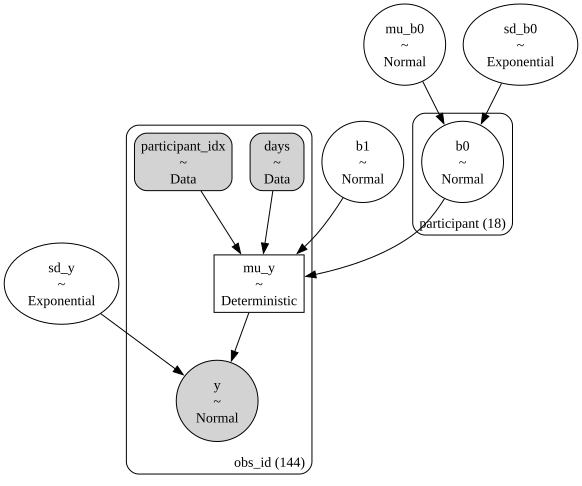

In [25]:
pm.model_to_graphviz(model)

## 3. Prior predictive check

### 3.1 What criteria will we use?

Use the prior-predictive criteria established in Notebook 1:

1. predicted reaction times should not routinely be physically impossible;
2. baseline reaction times should mostly occupy a broadly plausible range;
3. the model should allow plausible changes across the experiment without routinely generating absurd trajectories.

The hierarchical model adds one new criterion:

4. it should allow meaningful differences among participant baselines without routinely producing implausibly large between-participant differences.

### 3.2 Draw from the prior and prior predictive distributions.

Draw 500 samples and retain `mu_b0`, `sd_b0`, `b0`, `b1`, `sd_y`, `mu_y`, and `y`.

In [26]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500,
        var_names=["mu_b0", "sd_b0", "b0", "b1", "sd_y", "mu_y", "y"],
        random_seed=RANDOM_SEED,
    )

Sampling: [b0, b1, mu_b0, sd_b0, sd_y, y]


### 3.3 Which variables describe the population-level prior?

Which four scalar variables describe the population-level baseline distribution, common slope, and likelihood scale?

`mu_b0`, `sd_b0`, `b1`, and `sd_y`.

### 3.4 Plot the population-level priors.

Use `azp.plot_dist` with `group="prior"` for `mu_b0`, `sd_b0`, `b1`, and `sd_y`.

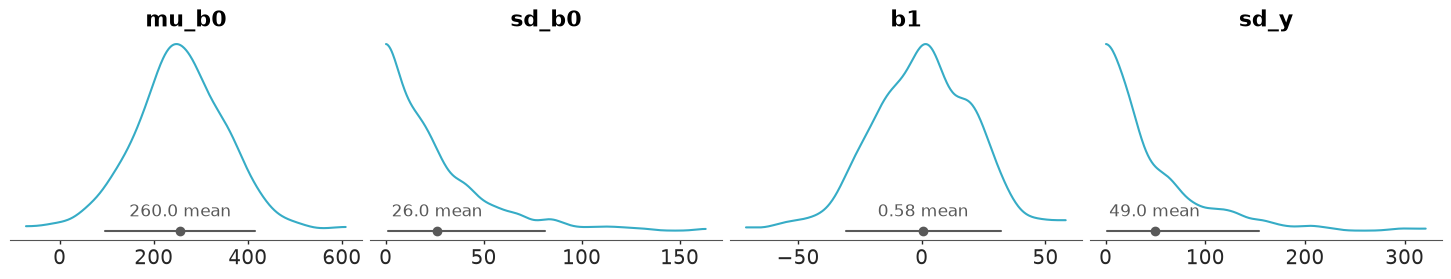

In [27]:
azp.plot_dist(
    prior,
    group="prior",
    var_names=["mu_b0", "sd_b0", "b1", "sd_y"],
    ci_prob=0.90,
    point_estimate="mean",
);

### 3.5 What should these population-level priors allow?

Use these concrete criteria:

- `mu_b0`: population-average baseline reaction times should mostly be in the broad 50–450 ms range;
- `sd_b0`: participant baselines should be allowed to differ substantially, but extremely large between-participant spreads should not be routine;
- `b1`: retain the broad slope prior from Notebook 1;
- `sd_y`: retain the broad positive residual-scale prior from Notebook 1.

### 3.6 Do the population-level priors satisfy those criteria?

Yes. They preserve the broad baseline, slope, and residual-scale assumptions from Notebook 1 while adding a moderately broad distribution for between-participant baseline variation.

### 3.7 Plot the prior predictive reaction times.

Use `plot_participants` to plot prior predictive `y`.

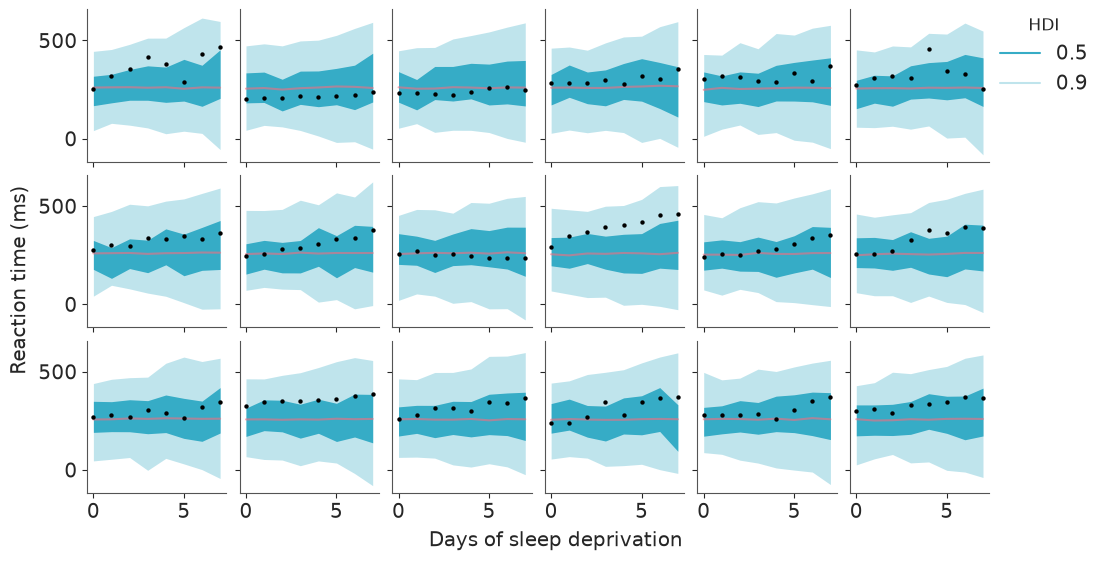

In [28]:
plot_participants(prior, "prior_predictive", "y")
plt.show()

### 3.8 Do the prior predictive samples satisfy the criteria from Question 3.1?

Broadly, yes. The hierarchy permits visible participant-to-participant baseline differences while retaining a broad range of plausible reaction-time trajectories.

## 4. Fit the hierarchical model

### 4.1 Sample from the posterior.

Draw 1000 posterior samples in each of 4 chains after 1500 tuning samples.

In [29]:
with model:
    idata = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        random_seed=RANDOM_SEED,
    )

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu_b0, sd_b0, b0, b1, sd_y]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 22 seconds.


## 5. Diagnose the fit

### 5.1 Which parameters should we check at the population level?

Which scalar posterior quantities describe the population baseline distribution, shared slope, and likelihood scale?

`mu_b0`, `sd_b0`, `b1`, and `sd_y`.

### 5.2 Calculate the numerical diagnostics for the population-level parameters.

Count divergences and use `azs.summary` with a 90% HDI.

In [30]:
print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))

population_summary = azs.summary(
    idata,
    var_names=["mu_b0", "sd_b0", "b1", "sd_y"],
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)
population_summary

Divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_b0,267.71,11.18,249.32,285.49,3544.57,3148.54,1.0,0.19,0.18
sd_b0,42.41,7.67,30.06,53.67,6867.93,3296.97,1.0,0.10,0.15
b1,11.41,1.12,9.52,13.20,1785.20,2188.43,1.0,0.03,0.02
sd_y,30.47,1.92,27.26,33.45,5752.56,3214.62,1.0,0.03,0.03


### 5.3 Plot the sampling diagnostics for the population-level parameters.

Use `azp.plot_trace_dist`.

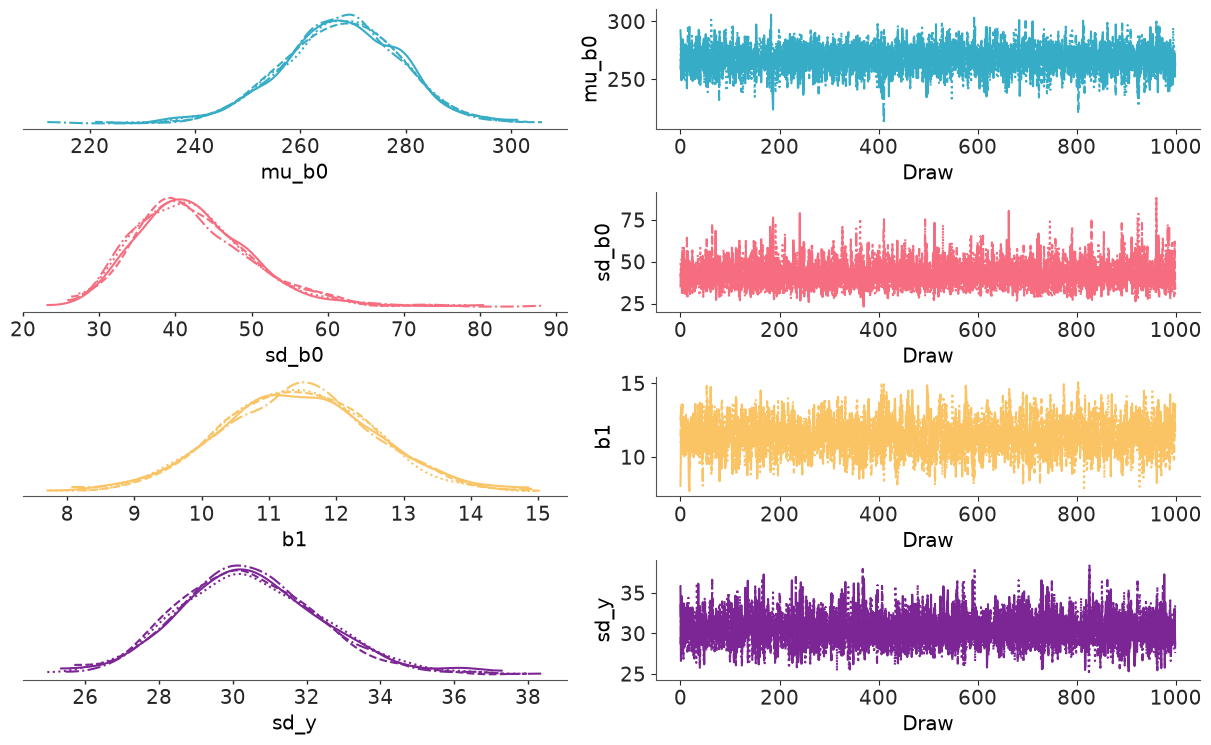

In [31]:
azp.plot_trace_dist(
    idata,
    var_names=["mu_b0", "sd_b0", "b1", "sd_y"],
);

### 5.4 Do the population-level parameters meet the diagnostic criteria from Notebook 1?

Yes, provided the executed notebook shows no divergences, R-hat values at or below 1.01, adequate bulk and tail ESS, and well-mixed traces.

### 5.5 Why not plot diagnostics for all participant-specific intercepts at once?

`b0` contains one posterior parameter for every participant. A smaller representative subset is easier to inspect.

### 5.6 Which ArviZ argument selects particular coordinate values?

Which argument can be used in both `azs.summary` and `azp.plot_trace_dist` to select specific participants?

The argument is `coords`.

### 5.7 Choose a small representative subset of participants.

In [32]:
diagnostic_participants = [
    participants[0],
    participants[len(participants) // 2],
    participants[-1],
]
diagnostic_coords = {"participant": diagnostic_participants}

diagnostic_participants

['308', '337', '372']

### 5.8 Calculate diagnostics for the selected participant-specific `b0` values.

In [33]:
azs.summary(
    idata,
    var_names=["b0"],
    coords=diagnostic_coords,
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b0[308],320.53,11.26,302.32,338.96,5051.22,2808.53,1.0,0.16,0.18
b0[337],345.98,11.07,328.50,364.90,4538.67,3031.32,1.0,0.16,0.17
b0[372],288.20,11.11,268.89,305.46,5862.16,3305.82,1.0,0.15,0.17


### 5.9 Plot diagnostics for the same `b0` values.

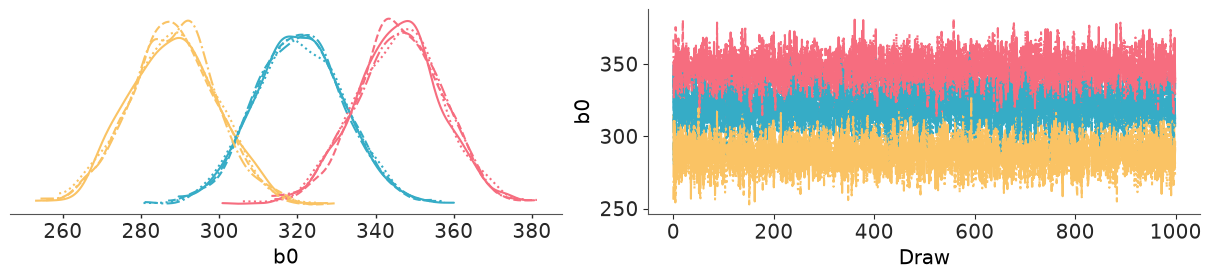

In [34]:
azp.plot_trace_dist(
    idata,
    var_names=["b0"],
    coords=diagnostic_coords,
);

### 5.10 Do the inspected participant-level parameters meet the diagnostic criteria?

Yes, provided their R-hat, ESS, and traces meet the same criteria used for the population-level parameters.

## 6. Examine the fitted hierarchy

### 6.1 What does `mu_b0` represent after fitting?

What posterior quantity gives the population-average baseline reaction time?

`mu_b0`.

### 6.2 Plot the posterior distribution of `mu_b0`.

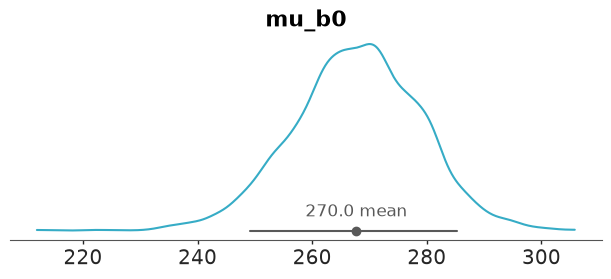

In [35]:
azp.plot_dist(
    idata,
    var_names=["mu_b0"],
    ci_prob=0.90,
    point_estimate="mean",
);

### 6.3 What does `sd_b0` represent after fitting?

Which posterior quantity measures between-participant variation in expected baseline reaction time?

`sd_b0`.

### 6.4 Plot the posterior distribution of `sd_b0`.

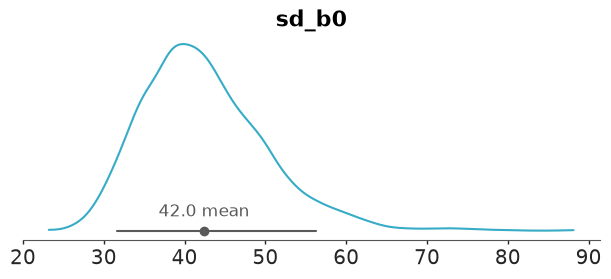

In [36]:
azp.plot_dist(
    idata,
    var_names=["sd_b0"],
    ci_prob=0.90,
    point_estimate="mean",
);

### 6.5 What does `sd_y` represent after fitting?

Which posterior quantity measures observation-to-observation variation around `mu_y`?

`sd_y`.

### 6.6 Plot the posterior distribution of `sd_y`.

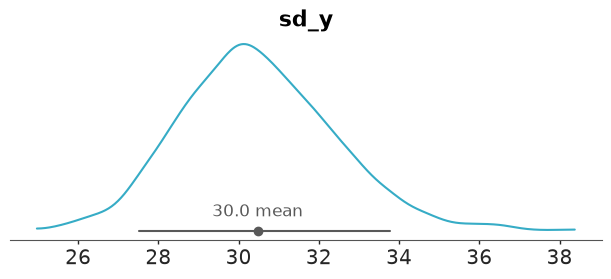

In [37]:
azp.plot_dist(
    idata,
    var_names=["sd_y"],
    ci_prob=0.90,
    point_estimate="mean",
);

### 6.7 Which ArviZ plot is designed to show intervals for many one-dimensional posterior quantities compactly?

We want to display the participant-specific `b0` values without making 18 separate density plots.

`azp.plot_forest`.

### 6.8 Plot the participant-specific posterior intercepts.

Use `azp.plot_forest` for `b0`, combining chains and showing 50% and 90% intervals.

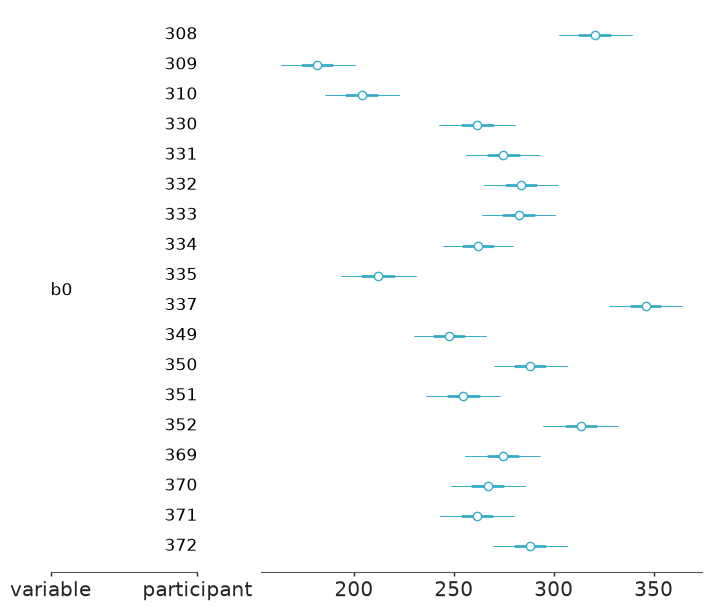

In [38]:
azp.plot_forest(
    idata,
    var_names=["b0"],
    combined=True,
    ci_probs=(0.50, 0.90),
    figure_kwargs={"figsize": (7, 6)},
);

### 6.9 What is partial pooling?

Because all participant-specific `b0` values are estimated through the shared population distribution `Normal(mu_b0, sd_b0)`, information is shared across participants rather than each participant being fitted independently.

This is **partial pooling**.

### 6.10 What does `b1` represent in this model?

Which posterior quantity is the common change in expected reaction time for one additional day of sleep deprivation?

`b1`.

### 6.11 Plot the posterior distribution of `b1`.

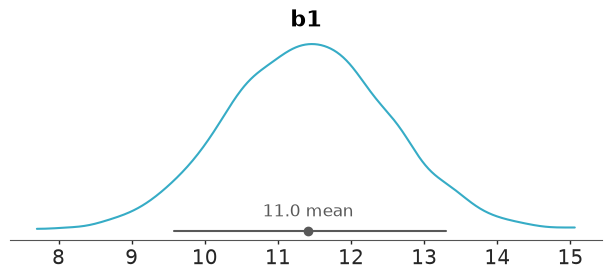

In [39]:
azp.plot_dist(
    idata,
    var_names=["b1"],
    ci_prob=0.90,
    point_estimate="mean",
);

### 6.12 Compare uncertainty in `b1` with Notebook 1.

Notebook 1 gave a 90% HDI for the population slope of approximately 7.94 to 14.07 ms/day.

Calculate the width of that interval and the width of the 90% HDI for `b1` in the current model.

In [40]:
notebook1_b1_hdi90 = (7.94, 14.07)
notebook1_width = notebook1_b1_hdi90[1] - notebook1_b1_hdi90[0]

current_width = (
    population_summary.loc["b1", "hdi90_ub"]
    - population_summary.loc["b1", "hdi90_lb"]
)

pd.DataFrame(
    {
        "90% HDI width (ms/day)": [notebook1_width, current_width],
    },
    index=["Notebook 1: population-only", "Notebook 4: varying intercept"],
)

,90% HDI width (ms/day)
Notebook 1: population-only,6.13
Notebook 4: varying intercept,3.68


### 6.13 Which model gives the more precise estimate of the common slope?

Use the calculated HDI widths.

The model with the smaller 90% HDI width gives the more precise estimate of the common slope. In the executed notebook, compare the two displayed values directly.

## 7. Posterior predictive check

### 7.1 What criteria will we use?

Use the established posterior-predictive criteria:

1. overall reaction-time level;
2. change across days;
3. observation-to-observation variation.

For this notebook, the main new question is whether the model reproduces persistent differences in overall reaction-time level among participants.

### 7.2 Generate posterior predictive reaction times.

In [41]:
with model:
    pm.sample_posterior_predictive(
        idata,
        var_names=["y"],
        extend_inferencedata=True,
        random_seed=RANDOM_SEED,
    )

Sampling: [y]


Output()

### 7.3 Which `plot_lm` argument selects particular participant coordinate values?

The supplied `plot_participants` helper passes this argument through to `azp.plot_lm`.

`coords`.

### 7.4 Plot posterior predictive reaction times.

First plot all participants.

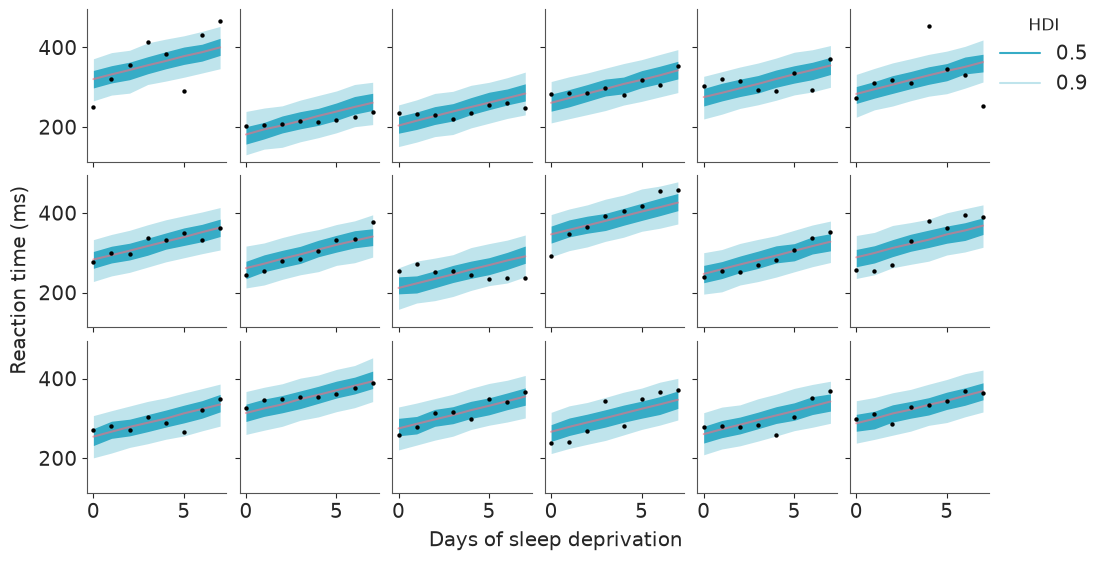

In [42]:
plot_participants(idata, "posterior_predictive", "y")
plt.show()

### 7.5 Does the model reproduce persistent participant differences in overall reaction-time level?

Apply the criterion stated in Question 7.1.

Yes. The varying-intercept structure lets the posterior predictive distributions follow persistent differences in participants' overall reaction-time levels much better than the population-only model.

## 8. What limitation remains?

### 8.1 How many slope parameters are in the model?

Does the model contain one `b1` for every participant or one `b1` shared by all participants?

There is one shared `b1`.

### 8.2 What does that imply about participant trajectories?

If participants have different `b0` values but all share the same `b1`, what must be true about their expected regression lines?

Their expected trajectories can differ in level, but they must have the same slope. The expected regression lines are parallel.

### 8.3 Plot a subset of participant-specific expected trajectories.

Use the same `coords` mechanism to make the parallel slopes easy to see.

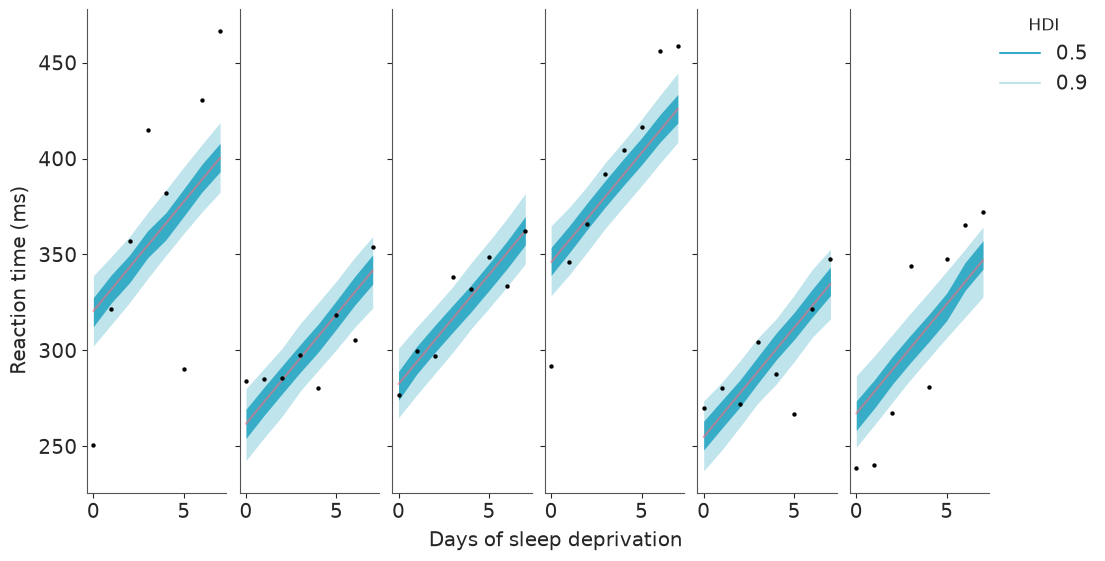

In [43]:
trajectory_participants = participants[::3]
trajectory_coords = {"participant": trajectory_participants}

plot_participants(
    idata,
    "posterior",
    "mu_y",
    coords=trajectory_coords,
)
plt.show()